# Import packages

In [28]:
import os
import datetime
import numpy as np
import pandas as pd
import nibabel as nib
import nilearn as nl
import glob
import matplotlib.pyplot as plt
from nilearn import plotting, glm

%matplotlib inline

# Set up filepaths

In [29]:
# EDIT: data_dir, sub_dirs

data_dir    = '/usr/people/snb3/neu502b/502b_analysis/'

results_dir = 'first_level_GLM' 

sub_dirs    = ['sub-001'] 

# Brain mask
Where's the grey matter? We can ignore stuff we don't care about

In [30]:
# make binary masks from fMRIprep outputted probability maps 

threshold = 0.4 # you can try out different thresholds, generally between .2 - .5

subject_masks = ['/usr/people/snb3/neu502b/502b_analysis/sub-001/ses-01/anat/sub-001_ses-01_acq-08mmXMPR_space-MNI152NLin2009cAsym_label-GM_probseg.nii.gz']
binary_subject_masks = [nib.Nifti1Image(
       (nib.load(p).get_fdata() > threshold).astype(np.uint8),
        nib.load(p).affine,
        nib.load(p).header
    )
    for p in subject_masks
]

In [15]:
# [ALT OPTION 2] load a generic mask (e.g., shaefer)
# [ALT OPTION 3] let nilearn guess where the grey matter is for you

### Check: Does mask look okay?

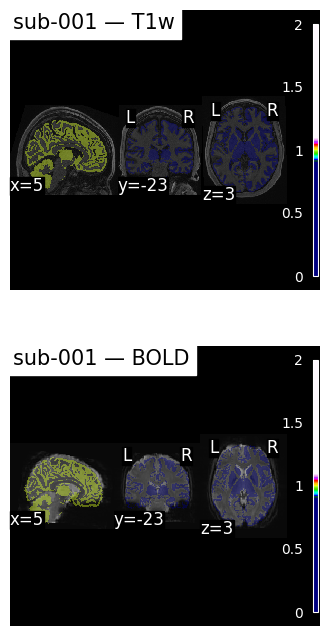

In [31]:
# make figure with 2 rows (anat, func) and N columns (subjects)
n_subs = len(sub_dirs)
fig, axes = plt.subplots(2, n_subs, figsize=(4 * n_subs, 8))

# edge case: if only one subject
if n_subs == 1:
    axes = axes.reshape(2, 1)

for idx,(mask,sub) in enumerate(zip(binary_subject_masks,sub_dirs)):
    anat_path = data_dir+sub+'/ses-01/anat/'+sub+'_ses-01_acq-08mmXMPR_space-MNI152NLin2009cAsym_desc-preproc_T1w.nii.gz'
    anat_img = nib.load(anat_path)

    boldref_path = data_dir+sub+'/ses-01/func/'+sub+'_ses-01_task-moral_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'
    boldref_4d = nib.load(boldref_path)
    boldref_img = boldref_4d.slicer[..., 0]   

    # show the mask overlaid on anatomical
    display_anat = plotting.plot_roi(mask,bg_img=anat_img,alpha=0.4,display_mode="ortho",draw_cross=False,axes=axes[0, idx],title=f"{sub} — T1w",figure=fig)
    
    # show the mask overlaid on functional
    display_func = plotting.plot_roi(mask,bg_img=boldref_img,alpha=0.4,display_mode="ortho",draw_cross=False,axes=axes[1, idx],title=f"{sub} — BOLD",figure=fig)

#plt.tight_layout()
plt.show()

# Event timing

In [ ]:
# events files for one subjects
events_file = '/jukebox/graziano/kirsten/502b_moral/pygers_workshop/sample_study/data/bids/sub-002/ses-01/func/sub-001_ses-01_task-moral_run-01_events.tsv'

In [49]:
# take a look at one events file

df = pd.read_table(events_file)
print(); print('Unique stimulus timings: '+str(df['trial_type'].unique()))
df.head(n=3)


Unique stimulus timings: []


,onset,duration,trial_type,response_time,stim_file,TODO -- fill in rows and add more tab-separated columns if desired


In [50]:
print(df.head())

Empty DataFrame
Columns: [onset, duration, trial_type, response_time, stim_file, TODO -- fill in rows and add more tab-separated columns if desired]
Index: []


In [ ]:
print(event_dfs[0].head())
print(event_dfs[0].columns.tolist())

### Choose the contrast to run

In [9]:
contrast = 'scrambled - veridical'

# NORMALLY: Exclude runs with too much motion

Typically, we exclude runs with too much motion. In our case, probably don't want to omit any data. You should still check the motion, though (adapt the function below)

It calls on the confounds file outputted by fmriprep for each subject:


- it is in the subject's fmriprep "func" folder and ends with "_desc-confounds_timeseries.tsv"

In [10]:
# def get_good_runs(data_dir, subject, percent_frames=.30, fwd=.5, exclude=[]):
#     '''
#     input   :  data_dir  - string - path to subject directories
#                subject   - string - subject directory
#     output  :  good_runs - list   - list of runs with <30% of frames with motion (>=.5 FWD)
#     '''
    
#     good_runs   = []
#     regressors  = []
    
#     for r in ['01']:    #['01','02','03','04','05','06']:
        
#         if r not in exclude:
        
#             df      = pd.read_csv(data_dir+subject+'/ses-01/func/'+subject+'_ses-01_task-PredictingAttention_run-'+r+'_desc-confounds_timeseries.tsv', sep="\t")
#             percent = df[df['framewise_displacement']>=fwd].shape[0] / df.shape[0]

#             # if bad motion in less than 30% of frames --> good run
#             if percent < percent_frames:
#                 good_runs.append(r)

#                 l = list(df['framewise_displacement']>.5)
#                 l_new = [int(x) for x in l]
#                 regressors.append(l_new)
        
#     return(good_runs,regressors)

# Create & run the model

You should generally do these things before / during first-level GLM.

You need to do each only once!

- smoothing <br/><br/>

- high pass filtering <br/><br/>

- nuisance regressors:<br/><br/>

    - a compcor - here I use the top 5 components, you may prefer more
        - 5 and 5 (5csf and 5 wm)
        
    - head motion, general
    
    - optional: head scrubbing

In [20]:
for subject,events,mask in zip(sub_dirs,events_file,binary_subject_masks):  
    
    # create model object 
    model = nl.glm.first_level.FirstLevelModel(
                                          t_r=2,
                                          hrf_model='glover',
                                          mask_img=mask,
                                          smoothing_fwhm=4, # 8, 6, 4, 2..? 
                                          standardize='zscore_sample', 
                                          signal_scaling=False,
                                          drift_model=None, # bc we use high-pass filtering from fMRIprep (confounds)
                                          minimize_memory=False)
                                          # high_pass= .01 <-- if we were using drift_model
    
                                          # standardize important, particularly for MVPA
                                          # normalizing across time or space (aka "demeaning")
                                          # more standard to do temporal (default for "True")
                                          # for MVPA --> better to do spatial :)
    
    # get the brain images for the runs you want 
    runs = ['1']
    image_list = [ data_dir+subject+'/ses-01/func/'+subject+'_ses-01_task-moral_run-'+x+'_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz' for x in runs ]
    full_data = [ nib.load(i) for i in image_list]
    n_frames = full_data[0].shape[-1]  # <- remember each run might have different # of frames 
    mask = nl.image.resample_to_img(mask, full_data[0], interpolation='nearest') 

    # get confounds for those runs (rom fMRIprep)
    strategy   = [ 'motion','wm_csf','global_signal','compcor','scrub','high_pass' ]
    confounds_all  = [ nl.interfaces.fmriprep.load_confounds(x, 
                                                        strategy = strategy, 
                                                        fd_threshold=0.5,
                                                        n_compcor = 5,
                                                        motion ='basic',
                                                        demean = False) for x in image_list ]#[0]
    
    # confounds notes: people may find 'global_signal' controversial..?
    # confounds notes: here, I use motion='basic' which uses 6 motion params; some people/ pipelines might use more, e.g. a 24-parameter model   

    # get "sample masks"; replace any cases of None with an array listing all frames
    sm_list = [x[1] for x in confounds_all]
    sm_list = [np.arange(n_frames) if x is None else x for x in sm_list]

    # make design matrices from event timings
    event_dfs = [ pd.read_table(events_file) ]
    design_matrices = []

    for e,c in zip(event_dfs, confounds_all):
        TR_array   = np.array([x*2 for x in np.arange(n_frames)])
        matrix = glm.first_level.make_first_level_design_matrix(TR_array, 
                                                                e, 
                                                                hrf_model='glover', 
                                                                drift_model=None,
                                                                add_regs = c[0])
        design_matrices.append(matrix)
        
    # fit the model
    print('fitting the model!')
    fitted_model = model.fit(full_data, 
                             design_matrices = design_matrices,
                             sample_masks    = sm_list)

    # compute contrasts
    z_score  = fitted_model.compute_contrast(contrast, output_type='z_score') # for viewing
    eff_size = fitted_model.compute_contrast(contrast, output_type='effect_size') # for analysis

    # make output directory if it doesn't exist
    path_base = 'first_level_GLM'; directory_path = results_dir 
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)

    # save contrasts
    contrast_label = contrast.replace(' ', '-')
    now = datetime.datetime.now(); date_time = now.strftime('%Y-%m-%d_%H-%M-%S') 
    basename = os.path.splitext(os.path.basename(events))[0]
    z_score.to_filename(os.path.join(directory_path, basename + '_' + contrast_label + '_' + date_time + '_' + subject +'_z-score.nii.gz'))
    eff_size.to_filename(os.path.join(directory_path, basename + '_' + contrast_label + '_' + date_time + '_' + subject +'_eff-size.nii.gz'))
    print('contrasts for sub '+ subject +'saved!'); print()

/tmp/ipykernel_966366/2056573414.py:49: UserWarning: The following unexpected columns in events data will be ignored: stim_file, response_time, TODO -- fill in rows and add more tab-separated columns if desired
  matrix = glm.first_level.make_first_level_design_matrix(TR_array,
/tmp/ipykernel_966366/2056573414.py:58: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  fitted_model = model.fit(full_data,


fitting the model!


/tmp/ipykernel_966366/2056573414.py:58: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  fitted_model = model.fit(full_data,


KeyboardInterrupt: 

In [ ]:
for subject,events,mask in zip(sub_dirs,events_file,binary_subject_masks):  
    
    # create model object 
    model = nl.glm.first_level.FirstLevelModel(
                                          t_r=2,
                                          hrf_model='glover',
                                          mask_img=mask,
                                          smoothing_fwhm=4, # 8, 6, 4, 2..? 
                                          standardize='zscore_sample', 
                                          signal_scaling=False,
                                          drift_model=None, # bc we use high-pass filtering from fMRIprep (confounds)
                                          minimize_memory=False)
                                          # high_pass= .01 <-- if we were using drift_model
    
                                          # standardize important, particularly for MVPA
                                          # normalizing across time or space (aka "demeaning")
                                          # more standard to do temporal (default for "True")
                                          # for MVPA --> better to do spatial :)
    
    # get the brain images for the runs you want 
    runs = ['01']
    image_list = [ data_dir+subject+'/ses-01/func/'+subject+'_ses-01_task-moral_run-'+x+'_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz' for x in runs ]
    full_data = [ nib.load(i) for i in image_list]
    n_frames = full_data[0].shape[-1]  # <- remember each run might have different # of frames 
    mask = nl.image.resample_to_img(mask, full_data[0], interpolation='nearest') 

    # get confounds for those runs (rom fMRIprep)
    strategy   = [ 'motion','wm_csf','global_signal','compcor','scrub','high_pass' ]
    confounds_all  = [ nl.interfaces.fmriprep.load_confounds(x, 
                                                        strategy = strategy, 
                                                        fd_threshold=0.5,
                                                        n_compcor = 5,
                                                        motion ='basic',
                                                        demean = False) for x in image_list ]#[0]
    
    # confounds notes: people may find 'global_signal' controversial..?
    # confounds notes: here, I use motion='basic' which uses 6 motion params; some people/ pipelines might use more, e.g. a 24-parameter model   

    # get "sample masks"; replace any cases of None with an array listing all frames
    sm_list = [x[1] for x in confounds_all]
    sm_list = [np.arange(n_frames) if x is None else x for x in sm_list]

    # make design matrices from event timings
    event_dfs = [ pd.read_table(events_file) ]
    design_matrices = []

    for e,c in zip(event_dfs, confounds_all):
        TR_array   = np.array([x*2 for x in np.arange(n_frames)])
        matrix = glm.first_level.make_first_level_design_matrix(TR_array, 
                                                                e, 
                                                                hrf_model='glover', 
                                                                drift_model=None,
                                                                add_regs = c[0])
        design_matrices.append(matrix)
        
    # fit the model
    print('fitting the model!')
    fitted_model = model.fit(full_data, 
                             design_matrices = design_matrices,
                             sample_masks    = sm_list)

    # compute contrasts
    z_score  = fitted_model.compute_contrast(contrast, output_type='z_score') # for viewing
    eff_size = fitted_model.compute_contrast(contrast, output_type='effect_size') # for analysis

    # make output directory if it doesn't exist
    path_base = 'first_level_GLM'; directory_path = results_dir 
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)

    # save contrasts
    contrast_label = contrast.replace(' ', '-')
    now = datetime.datetime.now(); date_time = now.strftime('%Y-%m-%d_%H-%M-%S') 
    basename = os.path.splitext(os.path.basename(events))[0]
    z_score.to_filename(os.path.join(directory_path, basename + '_' + contrast_label + '_' + date_time + '_' + subject +'_z-score.nii.gz'))
    eff_size.to_filename(os.path.join(directory_path, basename + '_' + contrast_label + '_' + date_time + '_' + subject +'_eff-size.nii.gz'))
    print('contrasts for sub '+ subject +'saved!'); print()


/tmp/ipykernel_966366/665865545.py:50: UserWarning: The following unexpected columns in events data will be ignored: stim_file, response_time, TODO -- fill in rows and add more tab-separated columns if desired
  matrix = glm.first_level.make_first_level_design_matrix(TR_array,
/tmp/ipykernel_966366/665865545.py:59: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  fitted_model = model.fit(full_data,


fitting the model!


/tmp/ipykernel_966366/665865545.py:59: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  fitted_model = model.fit(full_data,


ValueError: The expression (scrambled - veridical) is not valid. This could be due to defining the contrasts using design matrix columns that are invalid python identifiers.

# Peek at the results!

NOTE: First level GLM is probably not going to look like anything... That's normal!

In [1]:
# visualize the betas for each subject 



In [30]:
# visualize the z-scored values for each subject 



# Second level GLM

In [24]:
# Now you can try out a second level model

# https://nilearn.github.io/stable/modules/generated/nilearn.glm.second_level.SecondLevelModel.html

# Permutation analysis

In [25]:
# you can also try out a permutation analysis

These analyses just look for increase in BOLD area in one condition versus the other


There are lots of other things you can try! Review the topics we've covered in class as well as methods you see in papers you like :)

You can also reference the pygers flowchart for useful analysis tips and ideas:
    https://brainhack-princeton.github.io/handbook/content_pages/01-05-overview.html
    
### Remember to make use of the MRI coding notebooks you did in class !!!